In [2]:
#All the imports
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
from scipy.stats import kurtosis
from scipy.ndimage import maximum_filter, label
import multiprocessing as mp
import os

In [3]:
def compute_radial_spectrum(fld, dx, dy, dtype=float):
    nx, ny = fld.shape

    # Fourier wavenumbers
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K_perp = np.sqrt(KX**2 + KY**2)

    # Power spectrum density
    ff = np.abs(np.fft.ifft2(fld))**2   # use fft2, not ifft2
    P_flat = ff.ravel()
    K_flat = K_perp.ravel()

    # Radial bins
    dk = kx[1] - kx[0]
    k_bins = np.arange(0, np.max(K_flat) + dk, dk)
    nk = len(k_bins)
    P_k = np.zeros(nk, dtype=dtype)

    # Bin indices (vectorized)
    idx_float = K_flat / dk
    i1 = np.floor(idx_float).astype(int)
    i2 = i1 + 1
    w = idx_float - i1   # weight to upper bin

    # Accumulate into bins
    for i in range(len(K_flat)):
        if i1[i] >= 0 and i2[i] < nk:
            P_k[i1[i]] += P_flat[i] * (1 - w[i])
            P_k[i2[i]] += P_flat[i] * w[i]

    # Pack into recarray
    tags = ['kk', 'sp']
    sps = np.recarray((nk,), dtype=[(t, dtype) for t in tags])
    sps['kk'] = k_bins
    sps['sp'] = P_k / dk

    return sps

#Function Definitions
def partial_x_2d(f,dx):
    """Compute ∂f/∂x using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dx = np.zeros_like(f)
    
    # Central difference in x-direction (axis=0)
    df_dx[1:Nx-1, :] = (f[2:Nx, :] - f[0:Nx-2, :]) / (2 * dx)
    
    # Periodic boundaries (x-direction)
    df_dx[0, :] = (f[1, :] - f[-1, :]) / (2 * dx)
    df_dx[-1, :] = (f[0, :] - f[-2, :]) / (2 * dx)
    
    return df_dx

def partial_y_2d(f,dy):
    """Compute ∂f/∂y using 2nd-order central differences with periodic BCs."""
    Nx, Ny = f.shape
    df_dy = np.zeros_like(f)
    
    # Central difference in y-direction (axis=1)
    df_dy[:, 1:Ny-1] = (f[:, 2:Ny] - f[:, 0:Ny-2]) / (2 * dy)
    
    # Periodic boundaries (y-direction)
    df_dy[:, 0] = (f[:, 1] - f[:, -1]) / (2 * dy)
    df_dy[:, -1] = (f[:, 0] - f[:, -2]) / (2 * dy)
    
    return df_dy

def partial_x_fft(f, dx):
    """
    Calculate ∂f/∂x using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dx (float): Grid spacing in the x-direction.

    Returns:
        df_dx (2D np.array): Partial derivative ∂f/∂x.
    """
    nx, ny = f.shape
    kx = np.fft.fftfreq(nx, d=dx) * 2 * np.pi  # Wavenumbers in x
    kx = kx[:, np.newaxis]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dx_hat = 1j * kx * f_hat
    df_dx = np.fft.ifft2(df_dx_hat).real

    return np.array(df_dx)

def partial_y_fft(f, dy):
    """
    Calculate ∂f/∂y using FFT on a 2D grid.

    Parameters:
        f (2D np.array): Function values on a 2D grid (shape: Nx × Ny).
        dy (float): Grid spacing in the y-direction.

    Returns:
        df_dy (2D np.array): Partial derivative ∂f/∂y.
    """
    nx, ny = f.shape
    ky = np.fft.fftfreq(ny, d=dy) * 2 * np.pi  # Wavenumbers in y
    ky = ky[np.newaxis, :]                     # Make it 2D for broadcasting

    f_hat = np.fft.fft2(f)
    df_dy_hat = 1j * ky * f_hat
    df_dy = np.fft.ifft2(df_dy_hat).real

    return df_dy

def index_of_just_smaller(arr, value):
    arr = np.asarray(arr)
    mask = arr < value
    if not np.any(mask):
        return None  # No smaller value exists
    return np.argmax(np.where(mask, arr, -np.inf))

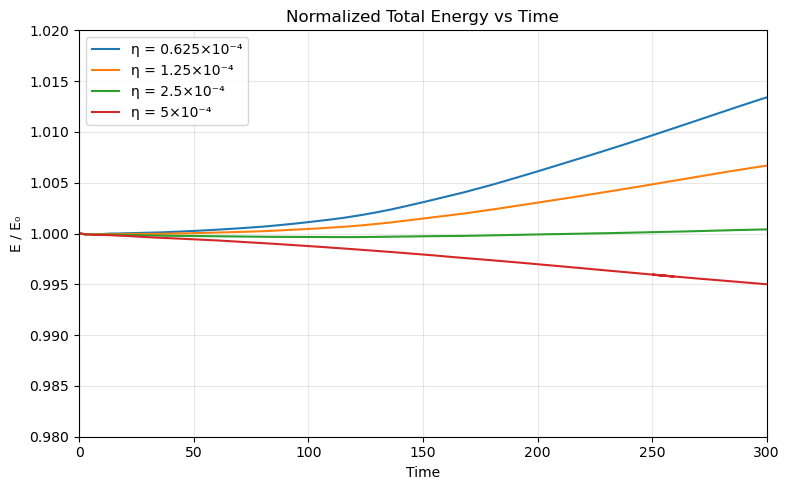

In [7]:
# --- File paths ---
File_Etot = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/EnTot_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/EnTot_ApJ_.h5'
]

File_Time = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Time_ApJ_.h5',
    '/DATA/DEVESH/ResistivityCheck/5e-4/Time_ApJ_.h5'
]

labels = [
    'η = 0.625×10⁻⁴',
    'η = 1.25×10⁻⁴',
    'η = 2.5×10⁻⁴',
    'η = 5×10⁻⁴'
]

# Helper function to load DS1 from a file
def load_dataset(fp):
    with h5py.File(fp, "r") as f:
        key = list(f.keys())[0]        # get first dataset name, e.g. 'DS1'
        return f[key][:]

# --- Load all runs ---
energies = []
times = []
for efile, tfile in zip(File_Etot, File_Time):
    energies.append(load_dataset(efile))
    times.append(load_dataset(tfile))

# --- Normalize energies ---
normalized = [E / E[0] for E in energies]

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.xlim(0, 300) 
plt.ylim(0.98, 1.02)

for t, Enorm, label in zip(times, normalized, labels):
    plt.plot(t, Enorm, label=label)

plt.xlabel("Time")
plt.ylabel("E / E₀")
plt.title("Normalized Total Energy vs Time")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("EnergyPlot.png", dpi=300)
plt.show()

In [8]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ResistivityCheck/0.625e-4',
    '/DATA/DEVESH/ResistivityCheck/1.25e-4',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048',
    '/DATA/DEVESH/ResistivityCheck/5e-4'
]

dx = 0.0625
dy = 0.0625

In [10]:
def process_sim_dir(sim_dir):
    J_rms = []
    for i in range(0, 300):
        File_Bx = f'{sim_dir}/Bx_ApJ_t{i}.h5'
        File_By = f'{sim_dir}/By_ApJ_t{i}.h5'

        with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
            data_Bx = fBx['DS1'][:].T
            data_By = fBy['DS1'][:].T

        J_par_FT = partial_x_fft(data_By, dx) - partial_y_fft(data_Bx, dy)
        rms = np.sqrt(np.mean(J_par_FT**2))
        J_rms.append(rms)

    return sim_dir, J_rms


if __name__ == "__main__":
    with mp.Pool(processes=8) as pool:   # adjust to number of CPU cores
        results = pool.map(process_sim_dir, sim_dirs)

    all_J_rms = {sim_dir: J_rms for sim_dir, J_rms in results}

In [9]:
def process_sim_dir(sim_dir):
    B_rms = []
    for i in range(0, 300):
        File_Bx = f'{sim_dir}/Bx_ApJ_t{i}.h5'
        File_By = f'{sim_dir}/By_ApJ_t{i}.h5'

        with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
            data_Bx = fBx['DS1'][:].T
            data_By = fBy['DS1'][:].T

        data_Bp = np.sqrt(data_Bx**2 + data_By**2)
        Bp_rms = np.sqrt(np.mean(data_Bp**2))
        B_rms.append(Bp_rms)

    return sim_dir, B_rms


if __name__ == "__main__":
    with mp.Pool(processes=8) as pool:   # adjust to number of CPU cores
        results = pool.map(process_sim_dir, sim_dirs)

    all_B_rms = {sim_dir: B_rms for sim_dir, B_rms in results}

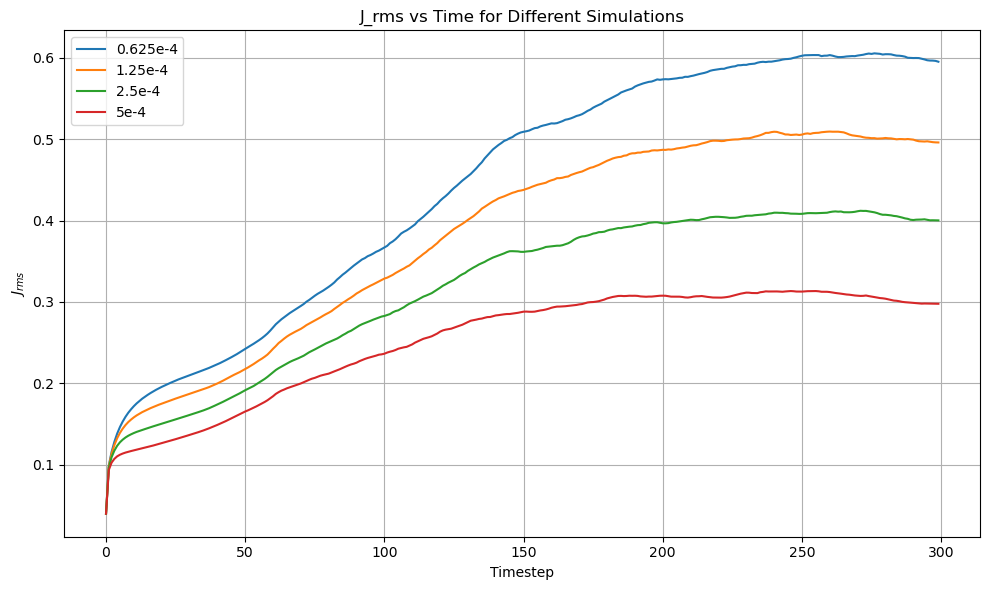

In [11]:
timesteps = np.arange(0, 300)

plt.figure(figsize=(10, 6))

for sim_dir, J_rms in all_J_rms.items():
    # Plot J_rms vs time for each simulation
    plt.plot(timesteps, J_rms, label=sim_dir.split('/')[-1])  # using last folder name as label

plt.xlabel('Timestep')
plt.ylabel(r'$J_{rms}$')
plt.title('J_rms vs Time for Different Simulations')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("Jrms.png", dpi=300)
plt.show()

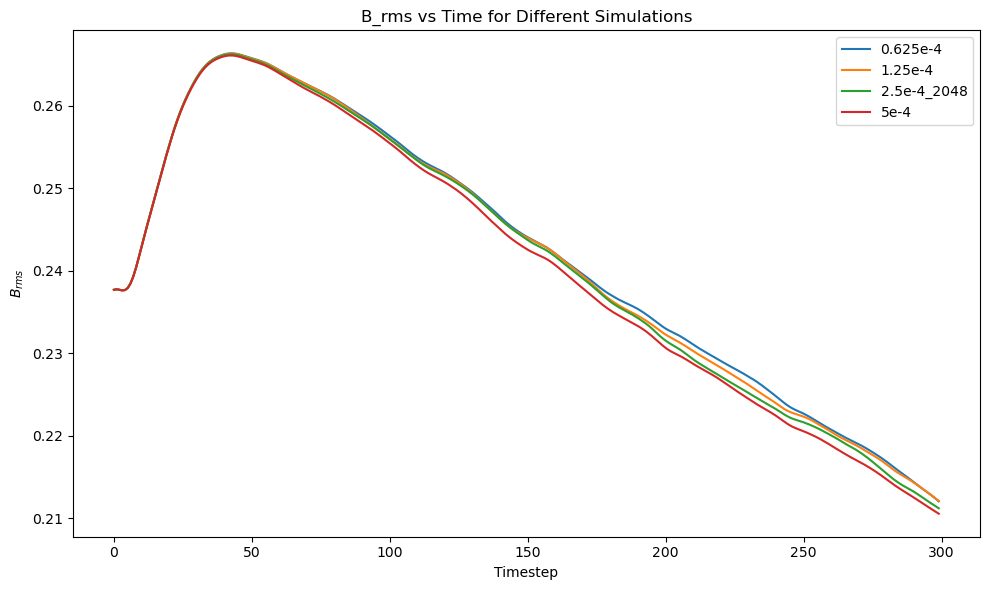

In [12]:
timesteps = np.arange(0, 300)

plt.figure(figsize=(10, 6))

for sim_dir, B_rms in all_B_rms.items():
    # Plot J_rms vs time for each simulation
    plt.plot(timesteps, B_rms, label=sim_dir.split('/')[-1])  # using last folder name as label

plt.xlabel('Timestep')
plt.ylabel(r'$B_{rms}$')
plt.title('B_rms vs Time for Different Simulations')
plt.legend()
# plt.grid(True)
plt.tight_layout()
plt.savefig("Brms.png", dpi=300)
plt.show()

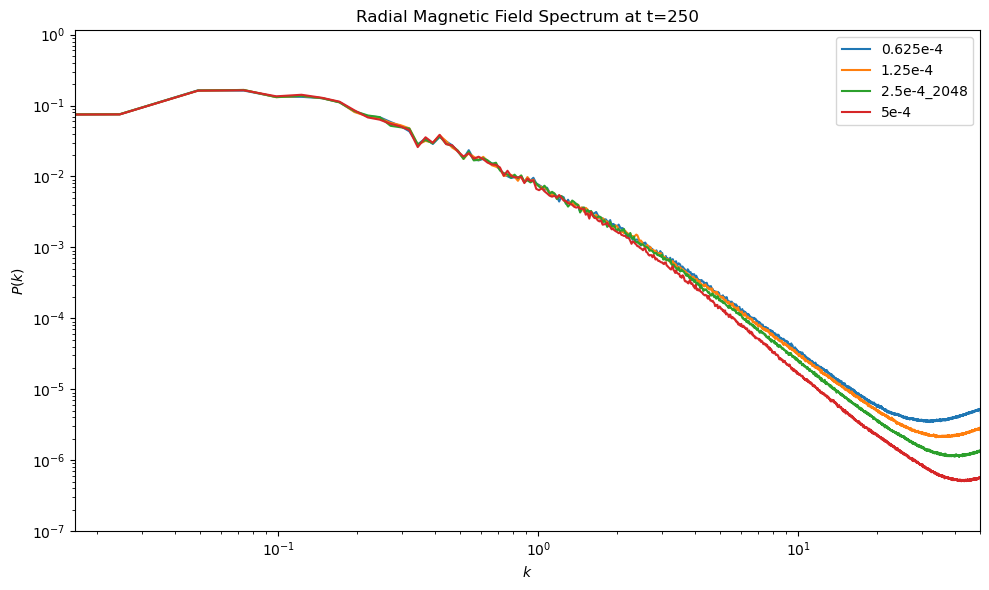

In [6]:
timestep = 250  # example timestep

plt.figure(figsize=(10, 6))

for sim_dir in sim_dirs:
    File_Bx = f'{sim_dir}/Bx_ApJ_t{timestep}.h5'
    File_By = f'{sim_dir}/By_ApJ_t{timestep}.h5'
    
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]
    
    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)
    
    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp
    
    # Plot
    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp, label=sim_dir.split('/')[-1])

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title(f'Radial Magnetic Field Spectrum at t={timestep}')
plt.legend()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_AllSimulations.png", dpi=300)
plt.show()

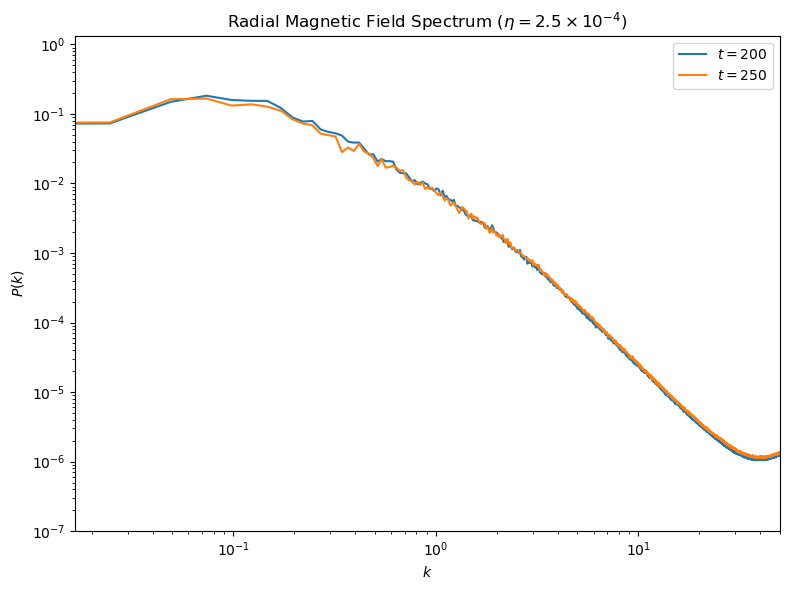

In [13]:
# Plotting Power Spectrum at t=200 and t=250 for resistivity of 2.5e-4

timesteps = [200, 250]

plt.figure(figsize=(8, 6))

for timestep in timesteps:
    File_Bx = f'/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/Bx_ApJ_t{timestep}.h5'
    File_By = f'/DATA/DEVESH/ResistivityCheck/2.5e-4_2048/By_ApJ_t{timestep}.h5'

    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]

    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)

    # Total perpendicular magnetic spectrum
    spectrum_Bp = np.recarray(
        spectrum_Bx.shape, dtype=spectrum_Bx.dtype
    )
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp

    # Plot
    plt.loglog(
        spectrum_Bp.kk,
        spectrum_Bp.sp,
        label=fr"$t={timestep}$"
    )

plt.xlabel(r"$k$")
plt.ylabel(r"$P(k)$")
plt.title(r"Radial Magnetic Field Spectrum ($\eta=2.5\times10^{-4}$)")
plt.legend()
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_TwoTimes.png", dpi=300)
plt.show()

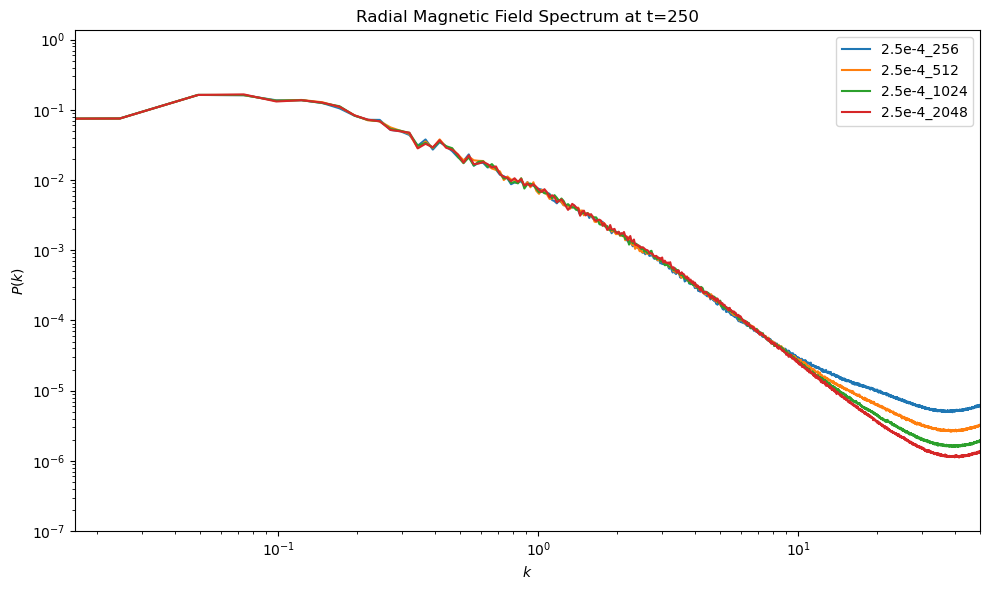

In [15]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_256',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_512',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_1024',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'
]

dx = 0.0625
dy = 0.0625

timestep = 250  # example timestep

plt.figure(figsize=(10, 6))

for sim_dir in sim_dirs:
    File_Bx = f'{sim_dir}/Bx_ApJ_t{timestep}.h5'
    File_By = f'{sim_dir}/By_ApJ_t{timestep}.h5'
    
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]
    
    # Compute radial spectra
    spectrum_Bx = compute_radial_spectrum(data_Bx, dx, dy)
    spectrum_By = compute_radial_spectrum(data_By, dx, dy)
    
    spectrum_Bp = np.recarray(spectrum_Bx.shape, dtype=spectrum_Bx.dtype)
    spectrum_Bp.kk = spectrum_Bx.kk
    spectrum_Bp.sp = spectrum_Bx.sp + spectrum_By.sp
    
    # Plot
    plt.loglog(spectrum_Bp.kk, spectrum_Bp.sp, label=sim_dir.split('/')[-1])

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title(f'Radial Magnetic Field Spectrum at t={timestep}')
plt.legend()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareBp_Differentppc.png", dpi=300)
plt.show()

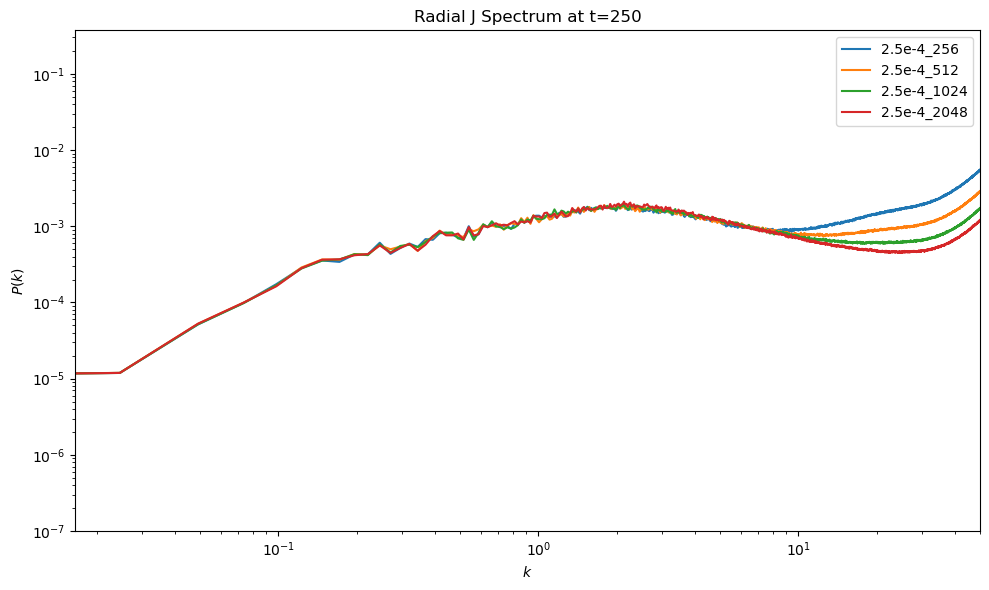

In [4]:
# List of simulation directories
sim_dirs = [
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_256',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_512',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_1024',
    '/DATA/DEVESH/ResistivityCheck/2.5e-4_2048'
]

dx = 0.0625
dy = 0.0625

timestep = 250  # example timestep

plt.figure(figsize=(10, 6))

for sim_dir in sim_dirs:
    File_Bx = f'{sim_dir}/Bx_ApJ_t{timestep}.h5'
    File_By = f'{sim_dir}/By_ApJ_t{timestep}.h5'
    File_Bz = f'{sim_dir}/Bz_ApJ_t{timestep}.h5'    
    
    with h5py.File(File_Bx, 'r') as fBx, h5py.File(File_By, 'r') as fBy, h5py.File(File_Bz, 'r') as fBz:
        data_Bx = fBx['DS1'][:]
        data_By = fBy['DS1'][:]
        data_Bz = fBz['DS1'][:]

    data_Jx = partial_y_fft(data_Bz,0.125)
    data_Jy = -partial_x_fft(data_Bz,0.125)
    data_Jz = partial_x_fft(data_By,0.125)-partial_y_fft(data_Bx,0.125)
    
    # Compute radial spectra
    spectrum_Jx = compute_radial_spectrum(data_Jx, dx, dy)
    spectrum_Jy = compute_radial_spectrum(data_Jy, dx, dy)
    spectrum_Jz = compute_radial_spectrum(data_Jz, dx, dy)
    
    spectrum_J = np.recarray(spectrum_Jx.shape, dtype=spectrum_Jx.dtype)
    spectrum_J.kk = spectrum_Jx.kk
    spectrum_J.sp = spectrum_Jx.sp + spectrum_Jy.sp + spectrum_Jz.sp
    
    # Plot
    plt.loglog(spectrum_J.kk, spectrum_J.sp, label=sim_dir.split('/')[-1])

plt.xlabel(r'$k$')
plt.ylabel(r'$P(k)$')
plt.title(f'Radial J Spectrum at t={timestep}')
plt.legend()
# plt.grid(True, which='both', ls='--', lw=0.5)
plt.xlim(None, 50)
plt.ylim(1e-7, None)
plt.tight_layout()
plt.savefig("CompareJ_Spectrum_Differentppc.png", dpi=300)
plt.show()